In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import matplotlib.patches as patches

Total contours with area > 1500: 26


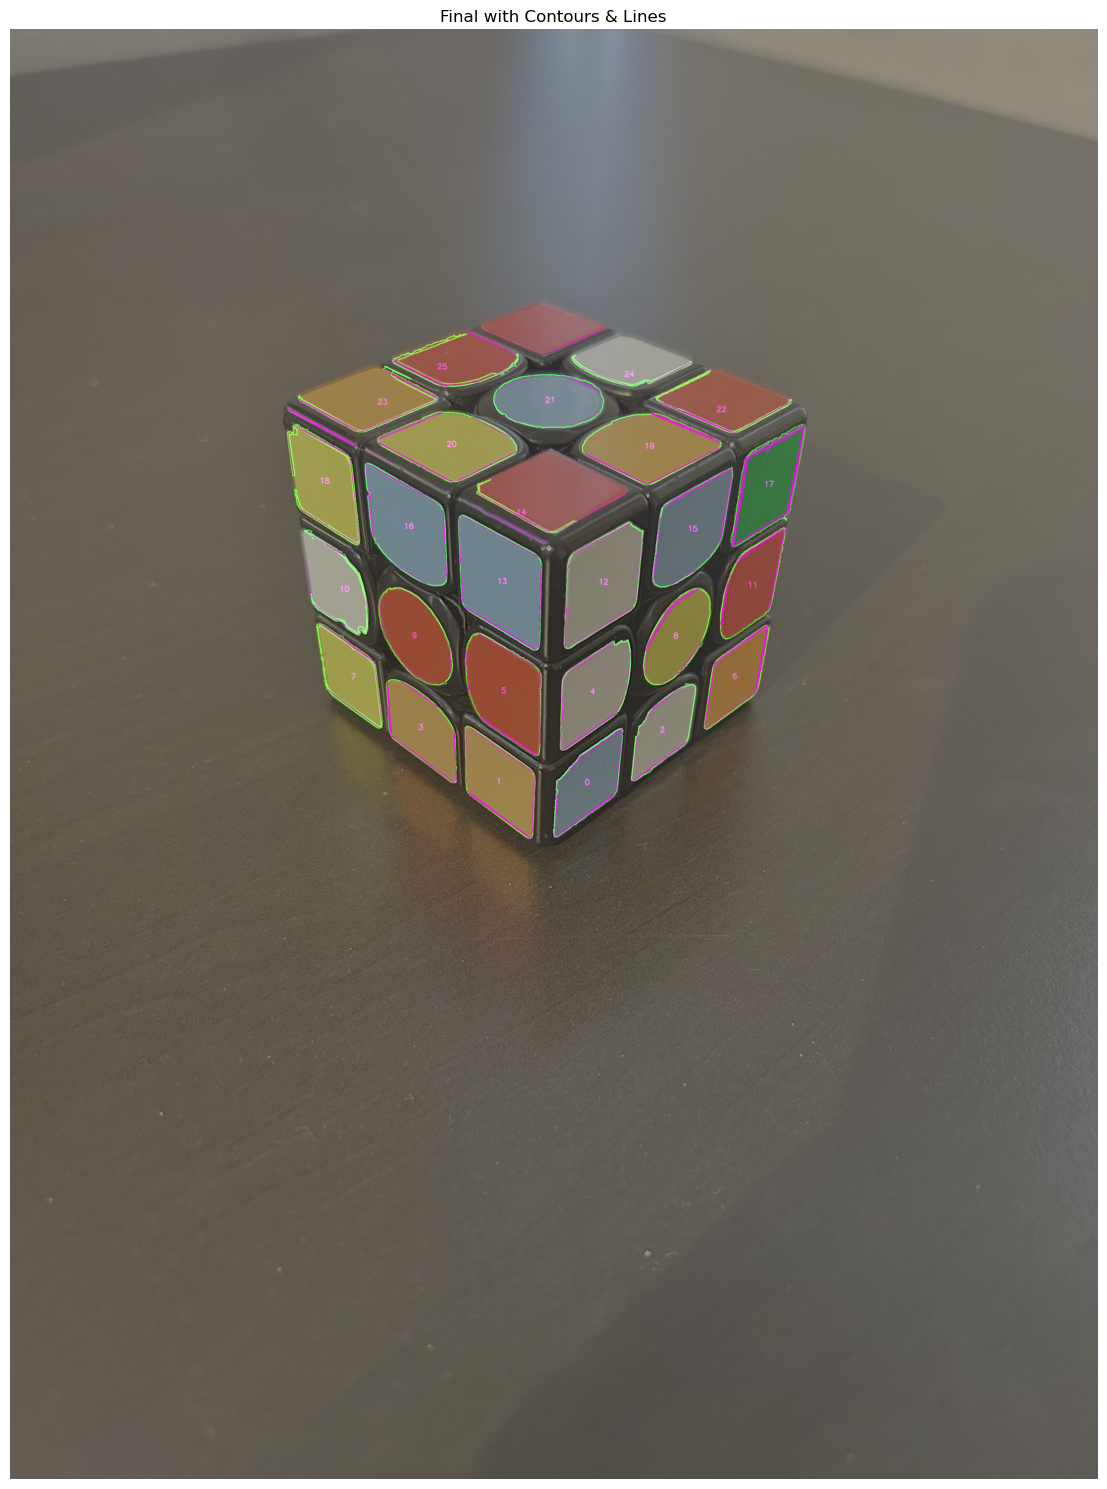

In [68]:
def preprocess_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(gray)
    blur = cv2.GaussianBlur(cl1, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    return edges


def dilate_edges(edges, kernel_size=(10, 10)):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    return cv2.dilate(edges, kernel, iterations=1)


def get_color_mask(hsv):
    masks = []

    # Red
    masks.append(cv2.inRange(hsv, np.array([0, 120, 70]), np.array([10, 255, 255])))
    masks.append(cv2.inRange(hsv, np.array([170, 120, 70]), np.array([180, 255, 255])))

    # Blue
    masks.append(cv2.inRange(hsv, np.array([90, 20, 100]), np.array([130, 255, 255])))

    # Green
    masks.append(cv2.inRange(hsv, np.array([40, 50, 50]), np.array([80, 255, 255])))

    # Yellow
    masks.append(cv2.inRange(hsv, np.array([20, 100, 100]), np.array([35, 255, 255])))

    # Orange
    masks.append(cv2.inRange(hsv, np.array([10, 100, 100]), np.array([20, 255, 255])))

    # White
    masks.append(cv2.inRange(hsv, np.array([0, 0, 130]), np.array([50, 90, 255])))

    full_mask = masks[0]
    for m in masks[1:]:
        full_mask = cv2.bitwise_or(full_mask, m)

    return full_mask


def clean_color_mask(mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)


def combine_edges_color(edges, color_mask):
    return cv2.bitwise_and(edges, color_mask)


def draw_hough_lines(img, edges, color=(255, 0, 255), thickness=1):
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=250, minLineLength=30, maxLineGap=10)
    out_img = img.copy()
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            cv2.line(out_img, (x1, y1), (x2, y2), color, thickness)
    return out_img


def detect_valid_contours(img, edges, min_area=1500):
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    overlay = np.zeros_like(img)  # Transparent overlay
    output = img.copy()           # Original image for blending
    valid_contours = []

    index = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < min_area:
            continue

        # Draw contour in green on overlay
        cv2.drawContours(overlay, [contour], -1, (0, 255, 0), 2)

        # Compute centroid and draw index in purple
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(overlay, str(index), (cx - 10, cy + 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)

        valid_contours.append(contour)
        index += 1

    # Blend overlay onto the original image (adjust alpha for stronger/weaker overlay)
    annotated_img = cv2.addWeighted(output, 1.0, overlay, 0.6, 0)

    print(f"Total contours with area > {min_area}: {len(valid_contours)}")
    return annotated_img, valid_contours




def show_images(titles, images):
    plt.figure(figsize=(15, 15))
    for i, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    img = cv2.imread("test_vids/config_1/1.png")

    edges = preprocess_image(img)
    dilated = dilate_edges(edges)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    raw_mask = get_color_mask(hsv)
    mask = clean_color_mask(raw_mask)

    combined = combine_edges_color(dilated, mask)

    # Use combined image for both contours and lines
    contour_img, facelets = detect_valid_contours(img, combined)
    final_img = draw_hough_lines(contour_img, combined)

    # show_images(["Edges", "Color Mask", "Combined", "Final with Contours & Lines"],
    #             [edges, mask, combined, final_img])
    show_images(["Final with Contours & Lines"],
                [final_img])



Detected 0 center circles


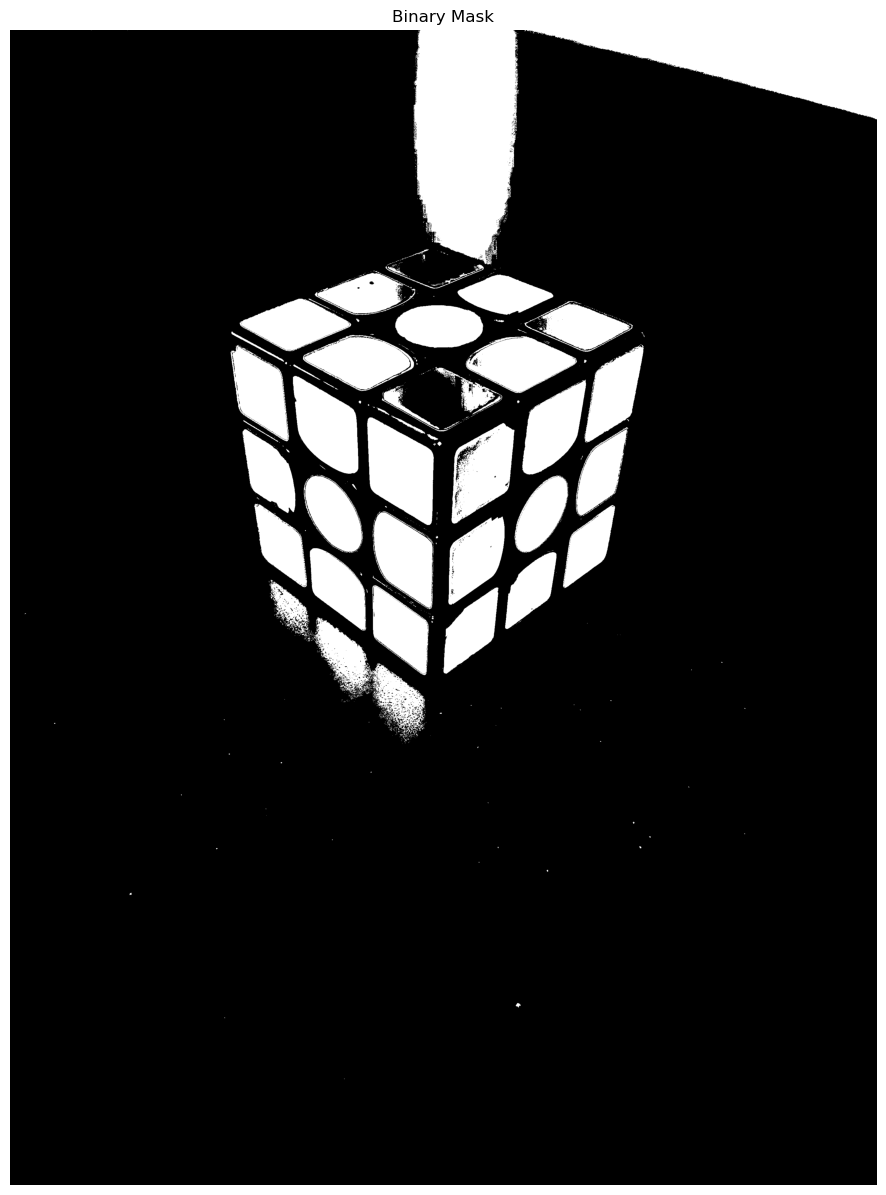

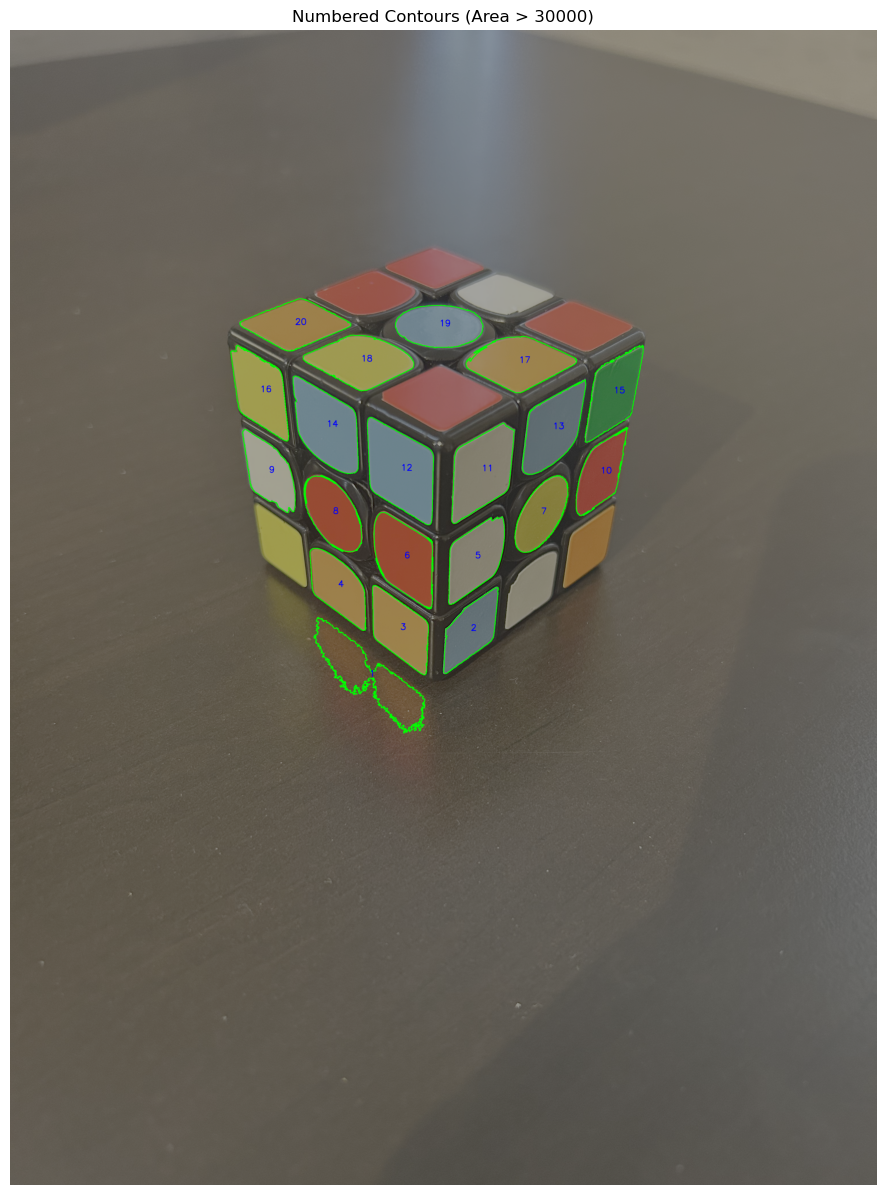

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

def classify_color(hsv_val):
    h, s, v = hsv_val
    if (0 <= h <= 10 or 170 <= h <= 180) and s >= 120 and v >= 70:
        return "red"
    elif 90 <= h <= 130 and s >= 20 and v >= 100:
        return "blue"
    elif 40 <= h <= 80 and s >= 50 and v >= 50:
        return "green"
    elif 20 <= h <= 35 and s >= 100 and v >= 100:
        return "yellow"
    elif 10 <= h <= 20 and s >= 100 and v >= 100:
        return "orange"
    elif s <= 50 and 130 <= v <= 255:
        return "white"
    else:
        return "unknown"



# --- Image preprocessing ---
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv_mask = get_color_mask(hsv)
contours, _ = cv2.findContours(hsv_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_overlay = img.copy()

# --- Contour filtering and annotation ---
circle_count = 0
center_circles = []
all_contours_info = []
contour_index = 1

for cnt in contours:
    area = cv2.contourArea(cnt)
    if 30000 < area < 100000:
        M = cv2.moments(cnt)
        cX, cY = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])) if M["m00"] != 0 else cnt[0][0]

        (x, y), radius = cv2.minEnclosingCircle(cnt)
        circle_area = np.pi * (radius ** 2)
        fit_ratio = area / circle_area

        cv2.drawContours(contour_overlay, [cnt], -1, (0, 255, 0), 2)

        info = {
            "contour": cnt,
            "centroid": (cX, cY),
            "area": area
        }

        if fit_ratio > 0.6:
            label = f"{contour_index} (circle)"
            circle_count += 1
            center_circles.append(info)
        else:
            label = str(contour_index)

        all_contours_info.append(info)

        cv2.putText(contour_overlay, label, (cX, cY),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)
        contour_index += 1

# --- Cube orientation dictionary ---
cube_orientation = {}

for idx, center_info in enumerate(center_circles):
    cnt = center_info["contour"]
    cX, cY = center_info["centroid"]

    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [cnt], -1, 255, thickness=-1)

    mean_hsv = cv2.mean(hsv, mask=mask)[:3]
    color_label = classify_color(mean_hsv)

    cube_orientation[f"center_{idx+1}"] = {
        "centroid": (cX, cY),
        "mean_hsv": [float(round(ch, 2)) for ch in mean_hsv],
        "color": color_label,
        "contour_area": float(cv2.contourArea(cnt))
    }

# --- Find 8 nearest neighbors for each center ---
cube_faces = []

for center_info in center_circles:
    center_centroid = np.array(center_info["centroid"])
    distances = []

    for other_info in all_contours_info:
        if np.array_equal(center_centroid, np.array(other_info["centroid"])):
            continue
        dist = np.linalg.norm(center_centroid - np.array(other_info["centroid"]))
        distances.append((dist, other_info))

    distances.sort(key=lambda x: x[0])
    closest_8 = [d[1] for d in distances[:8]]

    face = {
        "center": center_info,
        "neighbors": closest_8
    }
    cube_faces.append(face)

# --- Save enhanced cube faces JSON with color ---
cube_faces_serializable = []

for face in cube_faces:
    # Get color for center
    cnt = face["center"]["contour"]
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [cnt], -1, 255, -1)
    mean_hsv_center = cv2.mean(hsv, mask=mask)[:3]
    color_center = classify_color(mean_hsv_center)

    neighbors_serialized = []
    for n in face["neighbors"]:
        cnt_n = n["contour"]
        mask_n = np.zeros(hsv.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask_n, [cnt_n], -1, 255, -1)
        mean_hsv_n = cv2.mean(hsv, mask=mask_n)[:3]
        color_n = classify_color(mean_hsv_n)

        neighbors_serialized.append({
            "centroid": n["centroid"],
            "area": n["area"],
            "color": {
                "label": color_n,
                "mean_hsv": [float(round(ch, 2)) for ch in mean_hsv_n],
                "centroid": n["centroid"]  # already the centroid
            }
        })


    cube_faces_serializable.append({
        "center": {
            "centroid": face["center"]["centroid"],
            "area": face["center"]["area"],
            "color": color_center,
            "mean_hsv": [float(round(ch, 2)) for ch in mean_hsv_center]
        },
        "neighbors": neighbors_serialized
    })

with open("rubiks_cube_faces.json", "w") as f:
    json.dump(cube_faces_serializable, f, indent=4)

# --- Visualization ---
print(f"Detected {circle_count} center circles")

overlay_rgb = cv2.cvtColor(contour_overlay, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 15))
plt.imshow(hsv_mask, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 15))
plt.imshow(overlay_rgb)
plt.title("Numbered Contours (Area > 30000)")
plt.axis('off')
plt.show()


In [70]:
# Define color map
color_map = {
    "red": "#d50000",
    "orange": "#ff6d00",
    "yellow": "#ffeb3b",
    "green": "#388e3c",
    "blue": "#2962ff",
    "white": "#f5f5f5",
    "unknown": "#888888"
}

# Load face data
with open("rubiks_cube_faces.json", "r") as f:
    cube_face_data = json.load(f)

# Normalization function
def normalize(val, min_val, max_val):
    return (val - min_val) / (max_val - min_val) if max_val != min_val else 0.5

# Plot each face
for idx, face in enumerate(cube_face_data):
    tiles = [face["center"]] + face["neighbors"]

    # Extract centroids and colors
    positions = [tile["centroid"] for tile in tiles]
    colors = [tile["color"] if isinstance(tile["color"], str) else tile["color"].get("label", "unknown") for tile in tiles]

    xs = [pos[0] for pos in positions]
    ys = [pos[1] for pos in positions]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    norm_xs = [normalize(x, min_x, max_x) for x in xs]
    norm_ys = [normalize(y, min_y, max_y) for y in ys]

    # Create plot
    fig, ax = plt.subplots(figsize=(6, 6))
    margin = 0.1
    ax.set_xlim(-margin, 1 + margin)
    ax.set_ylim(-margin, 1 + margin)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Rubik's Cube Face {idx + 1}")

    for x, y, c in zip(norm_xs, norm_ys, colors):
        circle = patches.Circle(
            (x, 1 - y),  # Flip y-axis
            0.07,
            facecolor=color_map.get(c, "#888888"),
            edgecolor='black',
            lw=2
        )
        ax.add_patch(circle)
        ax.text(x, 1 - y, c[0].upper(), ha='center', va='center', fontsize=10, color='black')

    plt.show()


# Works so Far

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json


def classify_color(hsv_val):
    h, s, v = hsv_val

    # Red (usually needs two ranges to wrap around 0°)
    if 10 <= h <= 16 and s >= 150 and v >= 70:
        return "red"


    # Blue
    elif 95 <= h <= 125 and s >= 40 and v >= 110:
        return "blue"

    # Green
    elif 40 <= h <= 80 and s >= 50 and v >= 50:
        return "green"

    # Yellow
    elif 28 <= h <= 36 and s >= 100 and v >= 100:
        return "yellow"

    # Orange
    elif 23 <= h <= 29 and s >= 150 and v >= 100:
        return "orange"

    # White
    elif 25 <= h <= 35 and s <= 40 and v >= 200:
        return "white"




def get_color_mask(hsv):
    masks = []

    # Red
    masks.append(cv2.inRange(hsv, np.array([10, 150, 70]), np.array([16, 255, 255])))

    # Blue
    masks.append(cv2.inRange(hsv, np.array([95, 40, 110]), np.array([125, 255, 255])))

    # Green
    masks.append(cv2.inRange(hsv, np.array([40, 50, 50]), np.array([80, 255, 255])))

    # Yellow
    masks.append(cv2.inRange(hsv, np.array([28, 100, 100]), np.array([36, 255, 255])))

    # Orange
    masks.append(cv2.inRange(hsv, np.array([23, 150, 100]), np.array([29, 255, 255])))

    # White
    masks.append(cv2.inRange(hsv, np.array([25, 10, 200]), np.array([35, 40, 255])))

    full_mask = masks[0]
    for m in masks[1:]:
        full_mask = cv2.bitwise_or(full_mask, m)

    return full_mask


def extract_contours(img, hsv):
    hsv_mask = get_color_mask(hsv)
    contours, _ = cv2.findContours(hsv_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_overlay = img.copy()

    all_contours_info = []
    contour_index = 1

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 1000 < area < 50000:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
            else:
                cX, cY = cnt[0][0]

            # Draw contour outline
            cv2.drawContours(contour_overlay, [cnt], -1, (0, 255, 0), 2)

            info = {
                "contour": cnt,
                "centroid": (cX, cY),
                "area": area
            }

            all_contours_info.append(info)

            contour_index += 1

    total_objects = contour_index - 1
    print(f"Total objects detected: {total_objects}")

    return hsv_mask, contour_overlay, all_contours_info, total_objects


def identify_true_center_tile(contours_info):
    centroids = np.array([info["centroid"] for info in contours_info])
    if len(centroids) != 9:
        print("Warning: Expected 9 tiles for center identification")
        return None

    mean_centroid = np.mean(centroids, axis=0)
    distances = [np.linalg.norm(np.array(info["centroid"]) - mean_centroid) for info in contours_info]
    center_index = np.argmin(distances)
    return contours_info[center_index]


def build_faces(hsv, contours_info):
    true_center = identify_true_center_tile(contours_info)
    if true_center is None:
        return []

    center_centroid = np.array(true_center["centroid"])
    distances = []

    for other_info in contours_info:
        if np.array_equal(center_centroid, np.array(other_info["centroid"])):
            continue
        dist = np.linalg.norm(center_centroid - np.array(other_info["centroid"]))
        distances.append((dist, other_info))

    distances.sort(key=lambda x: x[0])
    closest_8 = [d[1] for d in distances[:8]]

    face = {
        "center": true_center,
        "neighbors": closest_8
    }
    return [face]


def save_faces_json(cube_faces, hsv, filename="rubiks_cube_faces.json"):
    cube_faces_serializable = []

    for face in cube_faces:
        cnt = face["center"]["contour"]
        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask, [cnt], -1, 255, -1)
        mean_hsv_center = cv2.mean(hsv, mask=mask)[:3]
        color_center = classify_color(mean_hsv_center)

        neighbors_serialized = []
        for n in face["neighbors"]:
            cnt_n = n["contour"]
            mask_n = np.zeros(hsv.shape[:2], dtype=np.uint8)
            cv2.drawContours(mask_n, [cnt_n], -1, 255, -1)
            mean_hsv_n = cv2.mean(hsv, mask=mask_n)[:3]
            color_n = classify_color(mean_hsv_n)

            neighbors_serialized.append({
                "centroid": n["centroid"],
                "area": n["area"],
                "color": {
                    "label": color_n,
                    "mean_hsv": [float(round(ch, 2)) for ch in mean_hsv_n]
                }
            })

        cube_faces_serializable.append({
            "center": {
                "centroid": face["center"]["centroid"],
                "area": face["center"]["area"],
                "color": color_center,
                "mean_hsv": [float(round(ch, 2)) for ch in mean_hsv_center]
            },
            "neighbors": neighbors_serialized
        })

    with open(filename, "w") as f:
        json.dump(cube_faces_serializable, f, indent=4)


def save_simplified_faces_json(cube_faces, hsv, filename="rubiks_cube_simplified.json"):
    simplified_data = []

    for face in cube_faces:
        cnt_center = face["center"]["contour"]
        mask_center = np.zeros(hsv.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask_center, [cnt_center], -1, 255, -1)
        mean_hsv_center = cv2.mean(hsv, mask=mask_center)[:3]
        color_center = classify_color(mean_hsv_center)

        neighbors_list = []
        for neighbor in face["neighbors"]:
            cnt_n = neighbor["contour"]
            mask_n = np.zeros(hsv.shape[:2], dtype=np.uint8)
            cv2.drawContours(mask_n, [cnt_n], -1, 255, -1)
            mean_hsv_n = cv2.mean(hsv, mask=mask_n)[:3]
            color_n = classify_color(mean_hsv_n)

            neighbors_list.append({
                "centroid": list(neighbor["centroid"]),
                "color": color_n
            })

        simplified_data.append({
            "center": {
                "centroid": list(face["center"]["centroid"]),
                "color": color_center
            },
            "neighbors": neighbors_list
        })

    with open(filename, "w") as f:
        json.dump(simplified_data, f, indent=4)


def visualize_results(hsv_mask, contour_overlay):
    overlay_rgb = cv2.cvtColor(contour_overlay, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(hsv_mask, cmap='gray')
    plt.title("Binary Mask")
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.imshow(overlay_rgb)
    plt.title("Numbered Contours")
    plt.axis('off')
    plt.show()


def main(video_path, target_frame=10):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
        return

    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Error: Could not read frame {target_frame} from {video_path}")
        return

    img = frame
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hsv_mask, contour_overlay, all_contours_info, total_objects = extract_contours(img, hsv)
    print(f"Detected {total_objects} total shapes.")

    cube_faces = build_faces(hsv, all_contours_info)
    save_faces_json(cube_faces, hsv)
    save_simplified_faces_json(cube_faces, hsv)
    visualize_results(hsv_mask, contour_overlay)


import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define color map
color_map = {
    "red": "#d50000",
    "orange": "#ff6d00",
    "yellow": "#ffeb3b",
    "green": "#388e3c",
    "blue": "#2962ff",
    "white": "#f5f5f5",
    "unknown": "#888888"
}

# Normalization function
def normalize(val, min_val, max_val):
    return (val - min_val) / (max_val - min_val) if max_val != min_val else 0.5

# Function to plot cube faces
def plot_rubiks_cube_faces(json_file="rubiks_cube_simplified.json"):
    with open(json_file, "r") as f:
        cube_face_data = json.load(f)

    for idx, face in enumerate(cube_face_data):
        tiles = [face["center"]] + face["neighbors"]

        positions = [tile["centroid"] for tile in tiles]
        colors = [tile["color"] if isinstance(tile["color"], str) else tile["color"].get("label", "unknown") for tile in tiles]

        xs = [pos[0] for pos in positions]
        ys = [pos[1] for pos in positions]

        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)

        norm_xs = [normalize(x, min_x, max_x) for x in xs]
        norm_ys = [normalize(y, min_y, max_y) for y in ys]

        # Create plot
        fig, ax = plt.subplots(figsize=(6, 6))
        margin = 0.1
        ax.set_xlim(-margin, 1 + margin)
        ax.set_ylim(-margin, 1 + margin)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f"Rubik's Cube Face {idx + 1}")

        for x, y, c in zip(norm_xs, norm_ys, colors):
            circle = patches.Circle(
                (x, 1 - y),  # Flip y-axis
                0.07,
                facecolor=color_map.get(c, "#888888"),
                edgecolor='black',
                lw=2
            )
            ax.add_patch(circle)
            ax.text(x, 1 - y, c[0].upper(), ha='center', va='center', fontsize=10, color='black')

        plt.show()


if __name__ == "__main__":
    video_file_path = "test_vids/config_1/cube.MOV"
    main(video_file_path)
    plot_rubiks_cube_faces()